In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix, parallel_coordinates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

In [39]:
df = pd.read_csv("monthly_all_four_sources_CLEANED_2019_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cbsa_code            936 non-null    int64  
 1   cbsa_proper_name     936 non-null    object 
 2   year                 936 non-null    int64  
 3   month                936 non-null    int64  
 4   aqi_mean_monthly     936 non-null    float64
 5   aqi_co               936 non-null    int64  
 6   aqi_no2              936 non-null    float64
 7   aqi_o3               936 non-null    float64
 8   aqi_pm10             936 non-null    float64
 9   aqi_pm25             936 non-null    float64
 10  aqi_other            936 non-null    float64
 11  bls_employment_rate  936 non-null    float64
 12  ndvi_mean_monthly    936 non-null    float64
 13  viirs_mean_ntl       936 non-null    float64
 14  date                 936 non-null    object 
dtypes: float64(9), int64(4), object(2)
memor

In [3]:
df.groupby(['year','month']).count()

cbsa_code  cbsa_proper_name  aqi_mean_monthly  aqi_co  aqi_no2  \
year month                                                                   
2019 1             13                13                13      13       13   
     2             13                13                13      13       13   
     3             13                13                13      13       13   
     4             13                13                13      13       13   
     5             13                13                13      13       13   
...               ...               ...               ...     ...      ...   
2024 8             13                13                13      13       13   
     9             13                13                13      13       13   
     10            13                13                13      13       13   
     11            13                13                13      13       13   
     12            13                13                13      13       13   

            aqi_o3  aqi_pm10  aqi_pm25  aqi_other  bls_employment_rate  \
year month                                                               
2019 1          13        13        13         13                   13   
     2          13        13        13         13                   13   
     3          13        13        13         13                   13   
     4          13        13        13         13                   13   
     5          13        13        13         13                   13   
...            ...       ...       ...        ...                  ...   
2024 8          13        13        13         13                   13   
     9          13        13        13         13                   13   
     10         13        13        13         13                   13   
     11         13        13        13         13                   13   
     12         13        13        13         13                   13   

            ndvi_mean_monthly  viirs_mean_ntl  date  
year month                                           
2019 1                     13              13    13  
     2                     13              13    13  
     3                     13              13    13  
     4                     13              13    13  
     5                     13              13    13  
...                       ...             ...   ...  
2024 8                     13              13    13  
     9                     13              13    13  
     10                    13              13    13  
     11                    13              13    13  
     12                    13              13    13  

[72 rows x 13 columns]

In [23]:
# ---------- 1. Prepare data ----------
df = df.sort_values(["cbsa_code", "year", "month"]).copy()
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

target = "bls_employment_rate"

# Drop identifiers and missing rows
drop_cols = ["cbsa_code", "cbsa_proper_name", "year", "month", "date", target]
features = [c for c in df.columns if c not in drop_cols]
df = df.dropna(subset=features + [target])

X = df[features]
y = df[target].values

# ---------- 2. Define preprocessing & models ----------
num_proc = ColumnTransformer([("num", StandardScaler(), features)], remainder="drop")

models = {
    "Linear": Pipeline([("prep", num_proc), ("mdl", LinearRegression())]),
    "Lasso":  Pipeline([("prep", num_proc), ("mdl", Lasso(alpha=0.01, max_iter=5000))]),
    "RF":     Pipeline([("prep", num_proc),
                        ("mdl", RandomForestRegressor(
                            n_estimators=400, min_samples_leaf=2, random_state=42))])
}

# ---------- 3. Time-series cross-validation ----------
tscv = TimeSeriesSplit(n_splits=5)

def eval_ts(name, pipe):
    r2s, maes, rmses = [], [], []
    for tr, te in tscv.split(X):
        pipe.fit(X.iloc[tr], y[tr])
        preds = pipe.predict(X.iloc[te])
        r2s.append(r2_score(y[te], preds))
        maes.append(mean_absolute_error(y[te], preds))
        rmses.append(root_mean_squared_error(y[te], preds))
    print(f"{name:8} | R²: {np.mean(r2s):.3f} ±{np.std(r2s):.3f} | "
          f"MAE: {np.mean(maes):.3f} | RMSE: {np.mean(rmses):.3f}")

for n, m in models.items():
    eval_ts(n, m)



Linear   | R²: -0.374 ±0.395 | MAE: 2.073 | RMSE: 2.942
Lasso    | R²: -0.343 ±0.368 | MAE: 2.048 | RMSE: 2.914
RF       | R²: -0.434 ±0.343 | MAE: 2.047 | RMSE: 3.013



Top 10 important features:
 viirs_mean_ntl       0.375727
aqi_mean_monthly     0.220278
ndvi_mean_monthly    0.206612
aqi_pm25             0.079124
aqi_o3               0.078098
aqi_other            0.026456
aqi_pm10             0.007672
aqi_no2              0.006032
aqi_co               0.000000
dtype: float64


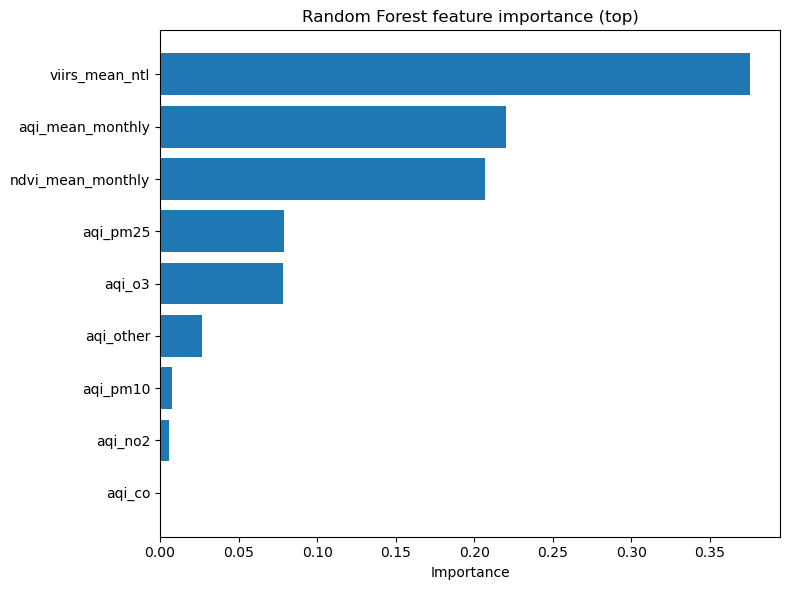

In [24]:
#---------- 4. Fit final model (best performer) ----------
best_model = models["RF"].fit(X, y)
rf = best_model.named_steps["mdl"]

# ---------- 5. Feature importance ----------
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop 10 important features:\n", importances.head(10))

# 

k = 15 if len(importances) > 15 else len(importances)
plt.figure(figsize=(8, 6))
plt.barh(importances.index[:k][::-1], importances.values[:k][::-1])
plt.title("Random Forest feature importance (top)")
plt.xlabel("Importance")
plt.tight_layout()

In [27]:
# ---------- 1. Prepare data ----------
df = df.sort_values(["cbsa_code", "year", "month"]).copy()
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

target = "bls_employment_rate"

# Create lag features for temporal context
df["lag1"] = df.groupby("cbsa_code")[target].shift(1)
df["lag3"] = df.groupby("cbsa_code")[target].shift(3)
df["roll3"] = df.groupby("cbsa_code")[target].shift(1).rolling(3).mean().reset_index(level=0, drop=True)

# Drop identifiers and missing rows
drop_cols = ["cbsa_code", "cbsa_proper_name", "year", "month", "date", target]
features = [c for c in df.columns if c not in drop_cols]
df = df.dropna(subset=features + [target])

X = df[features]
y = df[target].values

# ---------- 2. Define preprocessing & models ----------
num_proc = ColumnTransformer([("num", StandardScaler(), features)], remainder="drop")

models = {
    "Linear": Pipeline([("prep", num_proc), ("mdl", LinearRegression())]),
    "Lasso":  Pipeline([("prep", num_proc), ("mdl", Lasso(alpha=0.01, max_iter=5000))]),
    "RF":     Pipeline([("prep", num_proc),
                        ("mdl", RandomForestRegressor(
                            n_estimators=400, min_samples_leaf=2, random_state=42))])
}

# ---------- 3. Time-series cross-validation ----------
tscv = TimeSeriesSplit(n_splits=5)

def eval_ts(name, pipe):
    r2s, maes, rmses = [], [], []
    for tr, te in tscv.split(X):
        pipe.fit(X.iloc[tr], y[tr])
        preds = pipe.predict(X.iloc[te])
        r2s.append(r2_score(y[te], preds))
        maes.append(mean_absolute_error(y[te], preds))
        rmses.append(root_mean_squared_error(y[te], preds))
    print(f"{name:8} | R²: {np.mean(r2s):.3f} ±{np.std(r2s):.3f} | "
          f"MAE: {np.mean(maes):.3f} | RMSE: {np.mean(rmses):.3f}")

for n, m in models.items():
    eval_ts(n, m)



Linear   | R²: 1.000 ±0.000 | MAE: 0.000 | RMSE: 0.000
Lasso    | R²: 1.000 ±0.000 | MAE: 0.007 | RMSE: 0.010
RF       | R²: 0.996 ±0.005 | MAE: 0.051 | RMSE: 0.127


In [20]:
print(np.mean(r2s))
print(np.std(r2s))

/opt/anaconda3/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/anaconda3/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/anaconda3/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)


NameError: name 'r2s' is not defined


Top 10 important features:
 lag1                 0.831629
roll3                0.070411
lag3                 0.039416
aqi_mean_monthly     0.017680
viirs_mean_ntl       0.014060
ndvi_mean_monthly    0.010539
aqi_o3               0.007733
aqi_pm25             0.006421
aqi_other            0.001760
aqi_no2              0.000186
dtype: float64


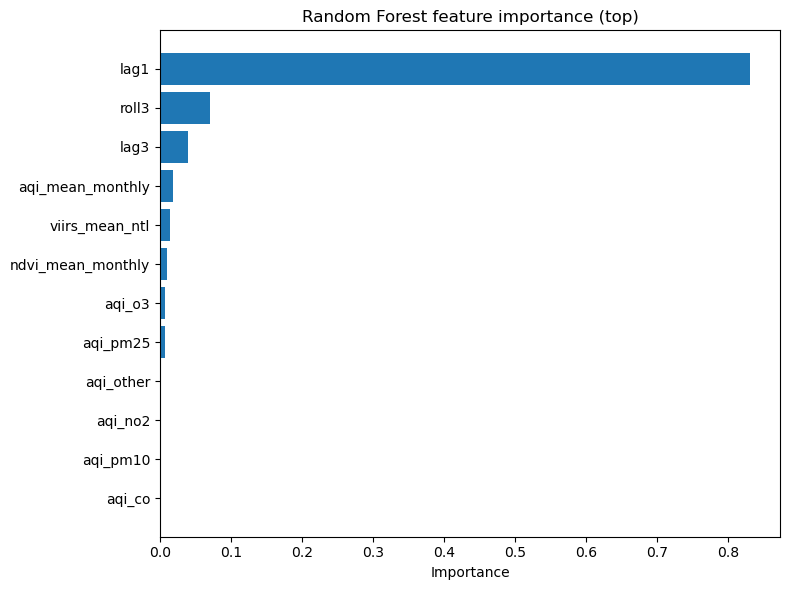

In [18]:
# ---------- 4. Fit final model (best performer) ----------
best_model = models["RF"].fit(X, y)
rf = best_model.named_steps["mdl"]

# ---------- 5. Feature importance ----------
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop 10 important features:\n", importances.head(10))


k = 15 if len(importances) > 15 else len(importances)
plt.figure(figsize=(8, 6))
plt.barh(importances.index[:k][::-1], importances.values[:k][::-1])
plt.title("Random Forest feature importance (top)")
plt.xlabel("Importance")
plt.tight_layout()

In [28]:
# ---------- 1) Prepare data: predict next month from this month ---------

df = df.sort_values(["cbsa_code", "year", "month"]).copy()
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

target = "bls_employment_rate"

# Step 1: NEXT-MONTH target (per CBSA) — forecast t+1 from info at t
df["target_next"] = df.groupby("cbsa_code")[target].shift(-1)


# Build feature set: keep all numeric columns except current/next target and IDs
id_cols = ["cbsa_code","cbsa_proper_name","year","month","date"]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
drop_from_X = set([target, "target_next"])  # drop current & next-month target from X
features = [c for c in num_cols if c not in drop_from_X]

# Drop rows where next-month target (or any feature) is missing
df_model = df.dropna(subset=["target_next"] + features).copy()
X = df_model[features]
y = df_model["target_next"].values

# ---------- 2) Define preprocessing & models ----------
num_proc = ColumnTransformer([("num", StandardScaler(), features)], remainder="drop")

models = {
    "Linear": Pipeline([("prep", num_proc), ("mdl", LinearRegression())]),
    "Lasso":  Pipeline([("prep", num_proc), ("mdl", Lasso(alpha=0.01, max_iter=5000))]),
    "RF":     Pipeline([("prep", num_proc),
                        ("mdl", RandomForestRegressor(
                            n_estimators=400, min_samples_leaf=2, random_state=42))]),
}

# ---------- 3) Time-series cross-validation ----------
tscv = TimeSeriesSplit(n_splits=5)

def eval_ts(name, pipe):
    r2s, maes, rmses = [], [], []
    for tr, te in tscv.split(X):
        pipe.fit(X.iloc[tr], y[tr])
        preds = pipe.predict(X.iloc[te])
        r2s.append(r2_score(y[te], preds))
        maes.append(mean_absolute_error(y[te], preds))
        rmses.append(root_mean_squared_error(y[te], preds))
    print(f"{name:8} | R²: {np.mean(r2s):.3f} ±{np.std(r2s):.3f} | "
          f"MAE: {np.mean(maes):.3f} | RMSE: {np.mean(rmses):.3f}")

for n, m in models.items():
    eval_ts(n, m)


Linear   | R²: 0.449 ±0.154 | MAE: 1.179 | RMSE: 1.829
Lasso    | R²: 0.479 ±0.128 | MAE: 1.126 | RMSE: 1.786
RF       | R²: 0.687 ±0.072 | MAE: 0.856 | RMSE: 1.423


In [40]:
# ---------- 1) Prepare data: predict next month from this month ---------

df = df.sort_values(["cbsa_code", "year", "month"]).copy()
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

target = "bls_employment_rate"

# Step 1: NEXT-MONTH target (per CBSA) — forecast t+1 from info at t
for lag in [1, 3]:
    df[f"{target}_lag{lag}"] = df.groupby("cbsa_code")[target].shift(lag)
df["ur_roll3"] = df.groupby("cbsa_code")[target].transform(lambda s: s.shift(1).rolling(3).mean())



# Build feature set: keep all numeric columns except current/next target and IDs
id_cols = ["cbsa_code","cbsa_proper_name","year","month","date"]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
drop_from_X = set([target, "target_next"])  # drop current & next-month target from X
features = [c for c in num_cols if c not in drop_from_X]

# Drop rows where next-month target (or any feature) is missing
df_model = df.dropna(subset=["target_next"] + features).copy()
X = df_model[features]
y = df_model["target_next"].values

# ---------- 2) Define preprocessing & models ----------
num_proc = ColumnTransformer([("num", StandardScaler(), features)], remainder="drop")

models = {
    "Linear": Pipeline([("prep", num_proc), ("mdl", LinearRegression())]),
    "Lasso":  Pipeline([("prep", num_proc), ("mdl", Lasso(alpha=0.01, max_iter=5000))]),
    "RF":     Pipeline([("prep", num_proc),
                        ("mdl", RandomForestRegressor(
                            n_estimators=400, min_samples_leaf=2, random_state=42))]),
}

# ---------- 3) Time-series cross-validation ----------
tscv = TimeSeriesSplit(n_splits=5)

def eval_ts(name, pipe):
    r2s, maes, rmses = [], [], []
    for tr, te in tscv.split(X):
        pipe.fit(X.iloc[tr], y[tr])
        preds = pipe.predict(X.iloc[te])
        r2s.append(r2_score(y[te], preds))
        maes.append(mean_absolute_error(y[te], preds))
        rmses.append(root_mean_squared_error(y[te], preds))
    print(f"{name:8} | R²: {np.mean(r2s):.3f} ±{np.std(r2s):.3f} | "
          f"MAE: {np.mean(maes):.3f} | RMSE: {np.mean(rmses):.3f}")

for n, m in models.items():
    eval_ts(n, m)

KeyError: ['target_next']

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   cbsa_code               936 non-null    int64         
 1   cbsa_proper_name        936 non-null    object        
 2   year                    936 non-null    int64         
 3   month                   936 non-null    int64         
 4   aqi_mean_monthly        936 non-null    float64       
 5   aqi_co                  936 non-null    int64         
 6   aqi_no2                 936 non-null    float64       
 7   aqi_o3                  936 non-null    float64       
 8   aqi_pm10                936 non-null    float64       
 9   aqi_pm25                936 non-null    float64       
 10  aqi_other               936 non-null    float64       
 11  bls_employment_rate     936 non-null    float64       
 12  ndvi_mean_monthly       936 non-null    float64   

In [35]:

# ---------- 1) Prepare data: predict next month from *lagged* predictors ----------
df = df.sort_values(["cbsa_code", "year", "month"]).copy()
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

target = "bls_employment_rate"

# next-month target (t+1), per CBSA (no leakage)
df["target_next"] = df.groupby("cbsa_code")[target].shift(-1)

# create 1-month lags of *predictors only* (use ONLY these in X)
predictor_base = [
    "aqi_mean_monthly","aqi_co","aqi_no2","aqi_o3","aqi_pm10","aqi_pm25","aqi_other",
    "ndvi_mean_monthly","viirs_mean_ntl"
]
for c in predictor_base:
    df[f"{c}_lag1"] = df.groupby("cbsa_code")[c].shift(1)


# feature set: ONLY lagged predictors 
lag_feats = [c for c in predictor_base]
features = lag_feats 

# drop rows where target_next or any feature is missing
df_model = df.dropna(subset=["target_next"] + features).copy()
X = df_model[features]
y = df_model["target_next"].values

# ---------- 2) Define preprocessing & models ----------
num_proc = ColumnTransformer([("num", StandardScaler(), features)], remainder="drop")

models = {
    "Linear": Pipeline([("prep", num_proc), ("mdl", LinearRegression())]),
    "Lasso":  Pipeline([("prep", num_proc), ("mdl", Lasso(alpha=0.01, max_iter=5000))]),
    "RF":     Pipeline([("prep", num_proc),
                        ("mdl", RandomForestRegressor(
                            n_estimators=400, min_samples_leaf=2, random_state=42))]),
}

# ---------- 3) Time-series cross-validation ----------
tscv = TimeSeriesSplit(n_splits=5)

def eval_ts(name, pipe):
    r2s, maes, rmses = [], [], []
    for tr, te in tscv.split(X):
        pipe.fit(X.iloc[tr], y[tr])
        preds = pipe.predict(X.iloc[te])
        r2s.append(r2_score(y[te], preds))
        maes.append(mean_absolute_error(y[te], preds))
        rmses.append(root_mean_squared_error(y[te], preds))
    print(f"{name:8} | R²: {np.mean(r2s):.3f} ±{np.std(r2s):.3f} | "
          f"MAE: {np.mean(maes):.3f} | RMSE: {np.mean(rmses):.3f}")

for n, m in models.items():
    eval_ts(n, m)


Linear   | R²: -0.225 ±0.195 | MAE: 1.890 | RMSE: 2.741
Lasso    | R²: -0.165 ±0.131 | MAE: 1.845 | RMSE: 2.681
RF       | R²: -0.592 ±0.636 | MAE: 2.127 | RMSE: 3.069


In [37]:

# ---------- 1) Prepare data ----------
df = df.sort_values(["cbsa_code", "year", "month"]).copy()
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

target = "bls_employment_rate"
# next-month target (t+1) per CBSA (no leakage)
df["target_next"] = df.groupby("cbsa_code")[target].shift(-1)

# current-month predictors
predictor_base = [
    "aqi_mean_monthly","aqi_co","aqi_no2","aqi_o3","aqi_pm10","aqi_pm25","aqi_other",
    "ndvi_mean_monthly","viirs_mean_ntl"
]

# add 1-month lags of predictors (t-1)
for c in predictor_base:
    df[f"{c}_lag1"] = df.groupby("cbsa_code")[c].shift(1)

# seasonality (no leakage)
df["m_sin"] = np.sin(2*np.pi*df["month"]/12.0)
df["m_cos"] = np.cos(2*np.pi*df["month"]/12.0)

# features = current month predictors + their lags + month encodings
lag_feats = [f"{c}_lag1" for c in predictor_base]
features = predictor_base + lag_feats + ["m_sin", "m_cos"]

# drop rows with missing target or features
df_model = df.dropna(subset=["target_next"] + features).copy()
X = df_model[features]
y = df_model["target_next"].values

# ---------- 2) Pipelines ----------
num_proc = ColumnTransformer([("num", StandardScaler(), features)], remainder="drop")

models = {
    "Linear": Pipeline([("prep", num_proc), ("mdl", LinearRegression())]),
    "Lasso" : Pipeline([("prep", num_proc), ("mdl", Lasso(alpha=0.01, max_iter=5000))]),
    "RF"    : Pipeline([("prep", num_proc),
                        ("mdl", RandomForestRegressor(
                            n_estimators=400, min_samples_leaf=2, random_state=42))]),
}

# ---------- 3) Time-series CV ----------
tscv = TimeSeriesSplit(n_splits=5)

def eval_ts(name, pipe):
    r2s, maes, rmses = [], [], []
    for tr, te in tscv.split(X):
        pipe.fit(X.iloc[tr], y[tr])
        preds = pipe.predict(X.iloc[te])
        r2s.append(r2_score(y[te], preds))
        maes.append(mean_absolute_error(y[te], preds))
        rmses.append(root_mean_squared_error(y[te], preds))
    print(f"{name:8} | R²: {np.mean(r2s):.3f} ±{np.std(r2s):.3f} | "
          f"MAE: {np.mean(maes):.3f} | RMSE: {np.mean(rmses):.3f}")

for n, m in models.items():
    eval_ts(n, m)


Linear   | R²: -0.877 ±1.010 | MAE: 2.402 | RMSE: 3.247
Lasso    | R²: -0.673 ±0.762 | MAE: 2.287 | RMSE: 3.106
RF       | R²: -0.684 ±0.768 | MAE: 2.275 | RMSE: 3.144


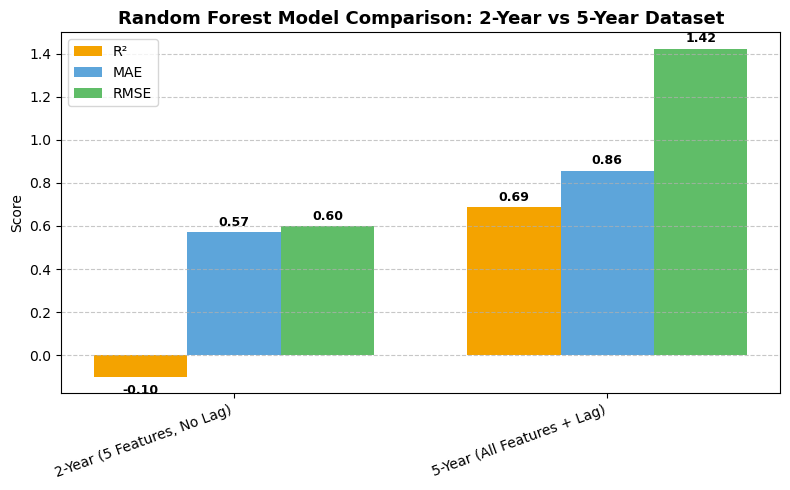

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Data
datasets = ["2-Year (5 Features, No Lag)", "5-Year (All Features + Lag)"]
r2 = [-0.10, 0.687]
mae = [0.57, 0.856]
rmse = [0.60, 1.423]

# Positions
x = np.arange(len(datasets))
width = 0.25

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Bars
ax.bar(x - width, r2, width, label="R²", color="#F4A300")
ax.bar(x, mae, width, label="MAE", color="#5DA5DA")
ax.bar(x + width, rmse, width, label="RMSE", color="#60BD68")

# Value labels
for i, val in enumerate(r2):
    ax.text(i - width, val + (0.03 if val >= 0 else -0.08), f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")
for i, val in enumerate(mae):
    ax.text(i, val + 0.03, f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")
for i, val in enumerate(rmse):
    ax.text(i + width, val + 0.03, f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")

# Styling
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Random Forest Model Comparison: 2-Year vs 5-Year Dataset", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()
